In [1]:
# First physical cell verifies complete byte contracts before imports or output.
from pathlib import Path
import hashlib, json
BASE = Path.cwd()
EXPECTED = {'data/posteriors.csv': 'd958b5713d0012db7186a7e63c77ff80069bee0ff7de54f3b3ed07daafd1b98b', 'data/label_shift.csv': '7964d15388fb422c8ff5f90d6d70d6fc019f752e80910f01f7a6ba47546b8f1c', 'data/decision_spec.json': 'fd00afbdeb107797b9631476d5a6de13ffc76beb605c6e5605fd29c78ce14f37', 'data_integrity.json': '29093baf11bea1d28568bb9086613c09996e8929df6eccd8fffac42a87a853d0', 'experiment.py': 'f1e7a79346c0549c6e4cc83e2a1e3f81b649d82f06be0e839d6745f9cc67be22', 'audit.py': 'c0f09b21bf6af5cb99ce08f0db25489663c7036d7214e4a7043323d0a41b157b', 'plots.py': '5491c15c1391298e836d7b692ecd1d8035d385b07af1d85051070d2fe47883d2', 'requirements.txt': 'cb0a0b450f412768b1fd6bfa3a779efc68cf2fb04651c3ebad61c1a360196763', 'environment.yml': '89461240297987037fbd340a7fa1dad366342c4ad77fb7a8b82c9a28380eb9cf'}
for relative, wanted in EXPECTED.items():
    if hashlib.sha256((BASE / relative).read_bytes()).hexdigest() != wanted:
        raise ValueError('Teaching contract changed: ' + relative)
print('All nine input/source/environment contracts verified.')

All nine input/source/environment contracts verified.


# 第045讲 从概率到决策

概率是固定合成机制的已知输入，不训练模型，也不将这份机制表当成未见测试数据。逐个真实状态算损失贡献，再选择行动。

Groups: [('D1', 0.0, 0.125), ('D2', 0.125, 0.125), ('D3', 0.25, 0.125), ('D4', 0.375, 0.125), ('D5', 0.5, 0.125), ('D6', 0.625, 0.125), ('D7', 0.875, 0.125), ('D8', 1.0, 0.125)]
Fixed config: {'kind': 'probability_to_decision_v1', 'false_positive_cost': 1.0, 'false_negative_cost': 3.0, 'reject_cost': 0.375, 'cost_pairs': [[1.0, 1.0], [1.0, 3.0], [3.0, 1.0], [0.0, 1.0], [1.0, 0.0], [0.0, 0.0]], 'thresholds': [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0], 'source_prior': 0.25, 'target_prior': 0.75, 'simulation_seed': 4505, 'samples_per_group': 256, 'multiclass_probabilities': [[0.5, 0.25, 0.25], [0.25, 0.25, 0.5]], 'multiclass_costs': [[0.0, 4.0, 4.0], [1.0, 0.0, 1.0], [1.0, 3.0, 0.0]], 'tie_rule': 'first listed action among exactly equal computed risks'}


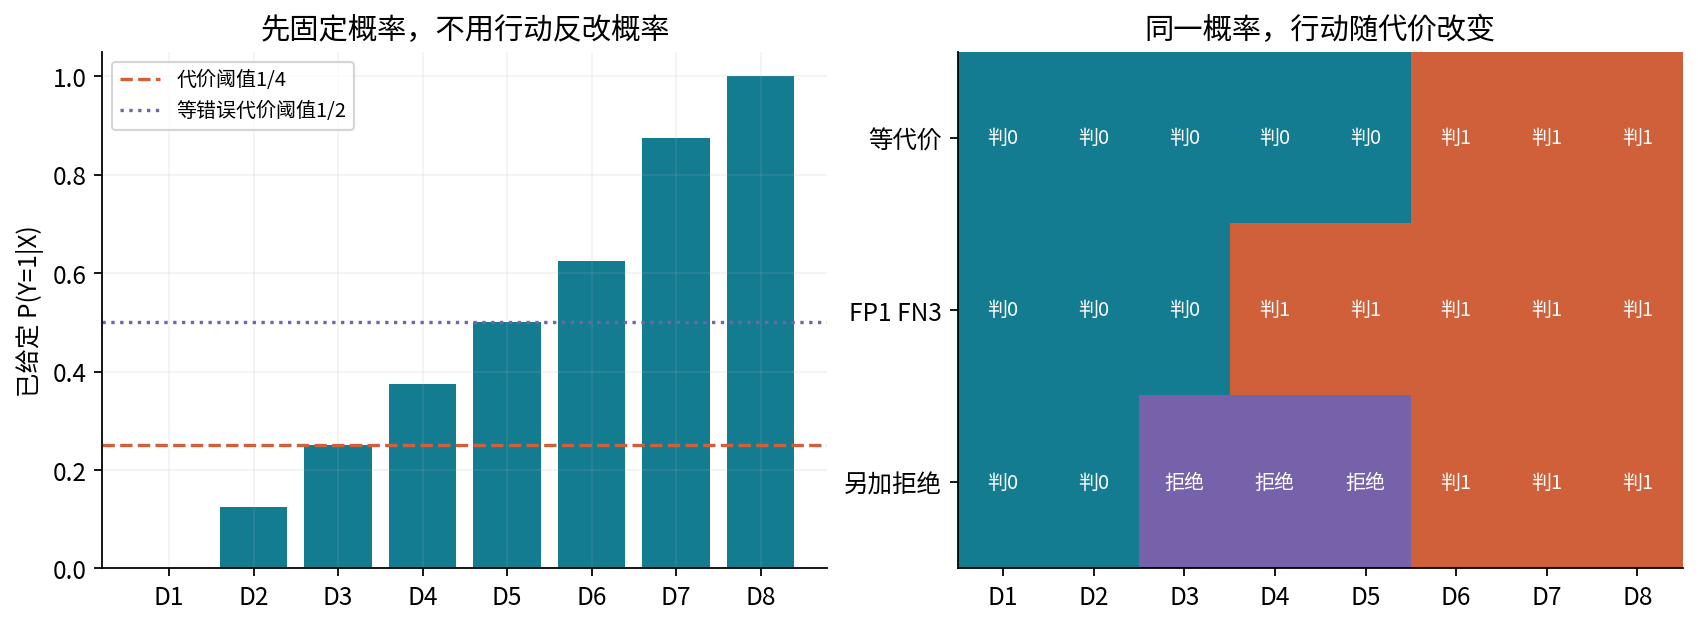

In [2]:
import os, io
os.environ.setdefault('MPLCONFIGDIR', str(BASE / 'outputs/mpl'))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e
import plots
p, w, ids, q0, q1, shift_ids, cfg = e.load_inputs()
report = e.main_report(p, w, ids, q0, q1, shift_ids, cfg)
P = np.column_stack([1-p, p])
def show(number):
    fig = plots.figure(number, report)
    stream = io.BytesIO()
    fig.savefig(stream, format='png', dpi=160, bbox_inches='tight')
    display(Image(data=stream.getvalue(), format='png'))
    plt.close(fig)
print('Groups:', list(zip(ids, p.tolist(), w.tolist())))
print('Fixed config:', cfg)
show(1)

## 一行的完整计算
D4每个真实状态的损失贡献是什么？为什么p小于1/2却选1？

D4 full decision chain: {'row': 1, 'posterior': [0.625, 0.375], 'class_loss_contributions': [[0.0, 1.125], [0.625, 0.0]], 'conditional_risks': [1.125, 0.625], 'chosen_action': 1, 'tied_actions': [1], 'minimum_conditional_risk': 0.625}
Cost-derived threshold: 0.25
Action order and tie rule: first listed action among exactly equal computed risks
Risk derivatives with respect to p: [3.0, -1.0, 0.0]


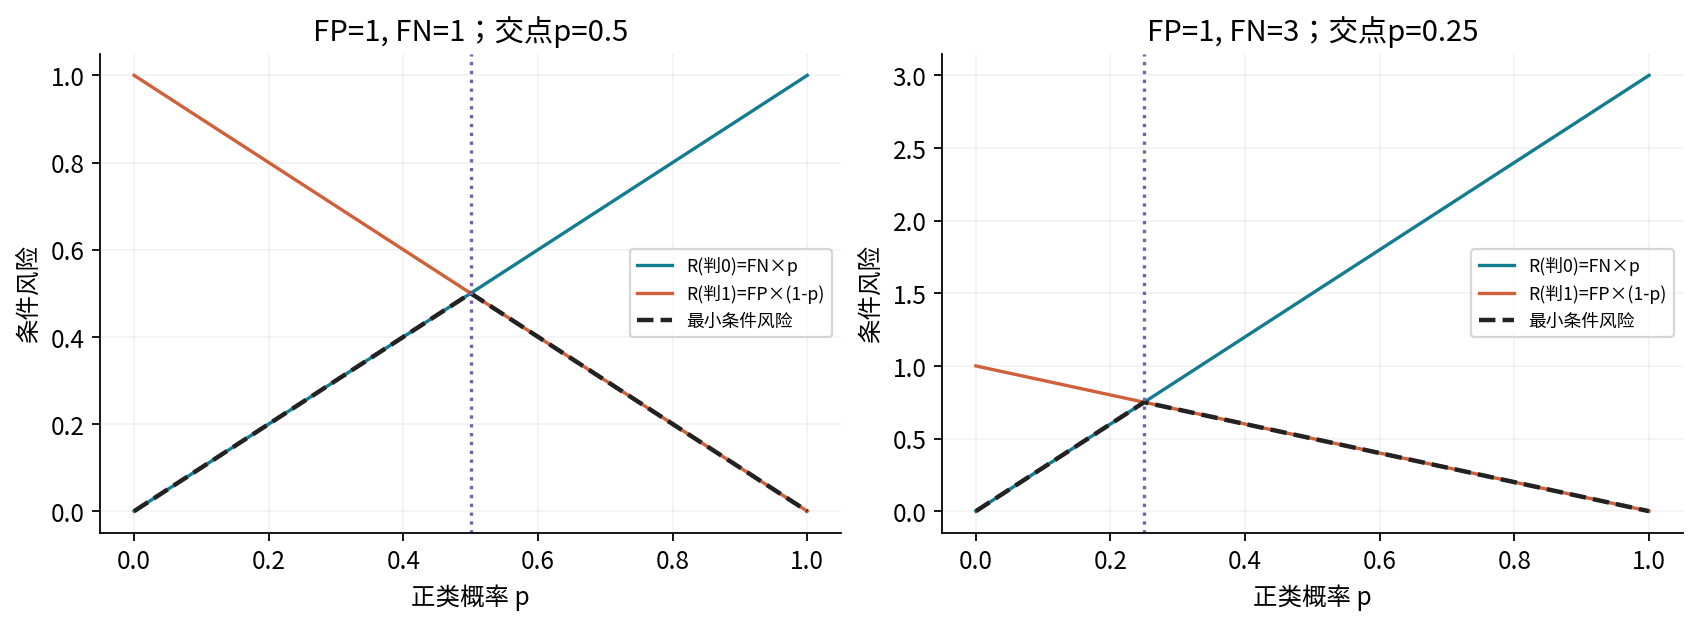

In [3]:
one = e.risk_table([[5/8, 3/8]], [[0, 3], [1, 0]])
print('D4 full decision chain:', one['rows'][0])
print('Cost-derived threshold:', report['binary_threshold'])
print('Action order and tie rule:', report['decision']['tie_rule'])
print('Risk derivatives with respect to p:', report['risk_derivatives_wrt_positive_probability'])
show(2)

## 相同概率下的三个完整阶段
各阶段都重新计算逐状态贡献、风险、并列集合和行动。改变成本不是更新模型参数。

STAGE: accuracy_decision
D1 {"chosen_action": 0, "class_loss_contributions": [[0.0, 0.0], [1.0, 0.0]], "conditional_risks": [0.0, 1.0], "minimum_conditional_risk": 0.0, "posterior": [1.0, 0.0], "row": 1, "tied_actions": [0]}
D2 {"chosen_action": 0, "class_loss_contributions": [[0.0, 0.125], [0.875, 0.0]], "conditional_risks": [0.125, 0.875], "minimum_conditional_risk": 0.125, "posterior": [0.875, 0.125], "row": 2, "tied_actions": [0]}
D3 {"chosen_action": 0, "class_loss_contributions": [[0.0, 0.25], [0.75, 0.0]], "conditional_risks": [0.25, 0.75], "minimum_conditional_risk": 0.25, "posterior": [0.75, 0.25], "row": 3, "tied_actions": [0]}
D4 {"chosen_action": 0, "class_loss_contributions": [[0.0, 0.375], [0.625, 0.0]], "conditional_risks": [0.375, 0.625], "minimum_conditional_risk": 0.375, "posterior": [0.625, 0.375], "row": 4, "tied_actions": [0]}
D5 {"chosen_action": 0, "class_loss_contributions": [[0.0, 0.5], [0.5, 0.0]], "conditional_risks": [0.5, 0.5], "minimum_conditional_risk": 0

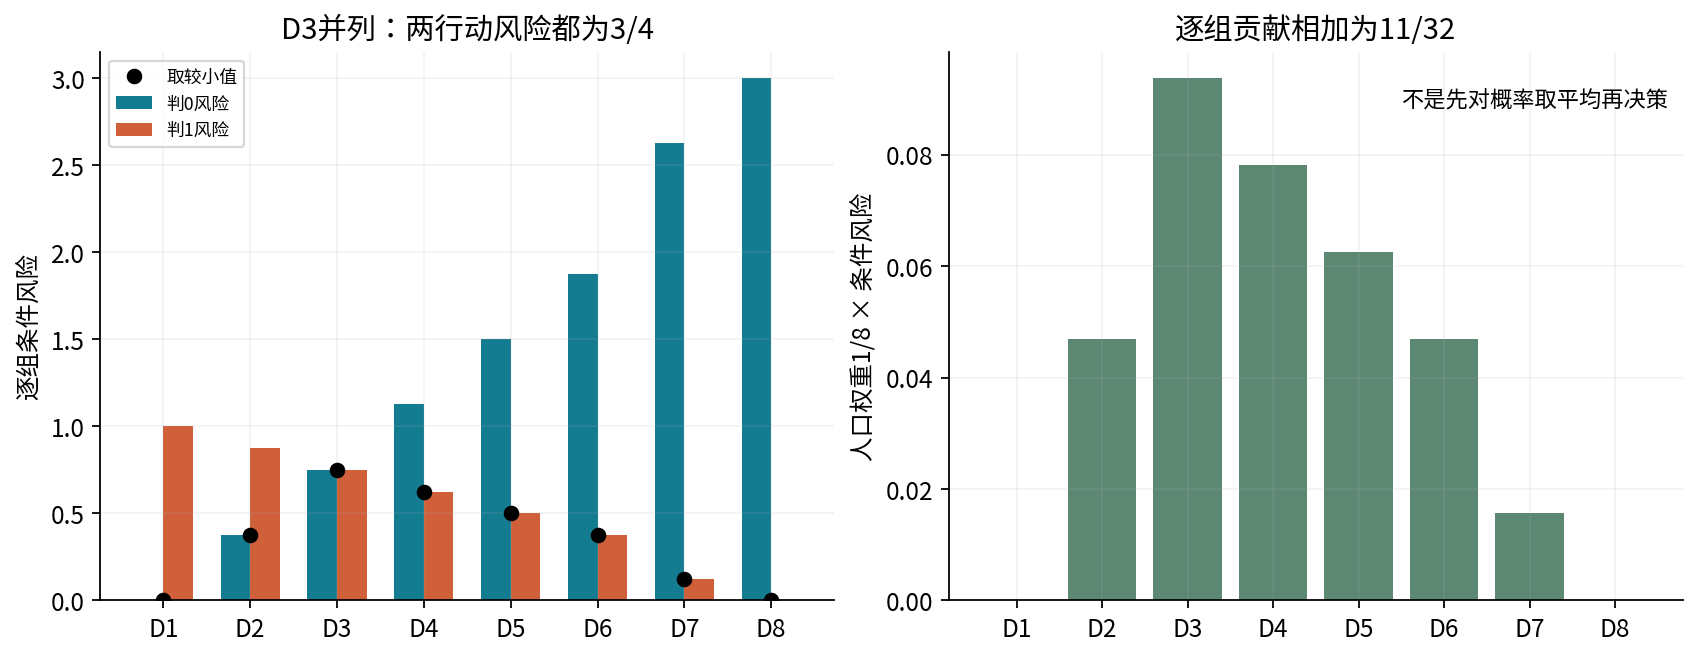

In [4]:
for name in ['accuracy_decision', 'decision', 'rejection']:
    print('STAGE:', name)
    for sid, row in zip(ids, report[name]['rows']):
        print(sid, json.dumps(row, ensure_ascii=False, sort_keys=True))
for name, result in report['evaluation'].items():
    print('POPULATION EVALUATION', name, result)
    if not np.isclose(sum(result['weighted_risk_contribution']), result['expected_cost'], rtol=1e-13, atol=1e-14):
        raise RuntimeError('Population contributions do not sum')
show(3)

Accuracy-optimal expected accuracy: 0.78125
Cost-optimal expected accuracy: 0.75
Accuracy rule actual cost: 0.53125
Cost rule actual cost: 0.34375


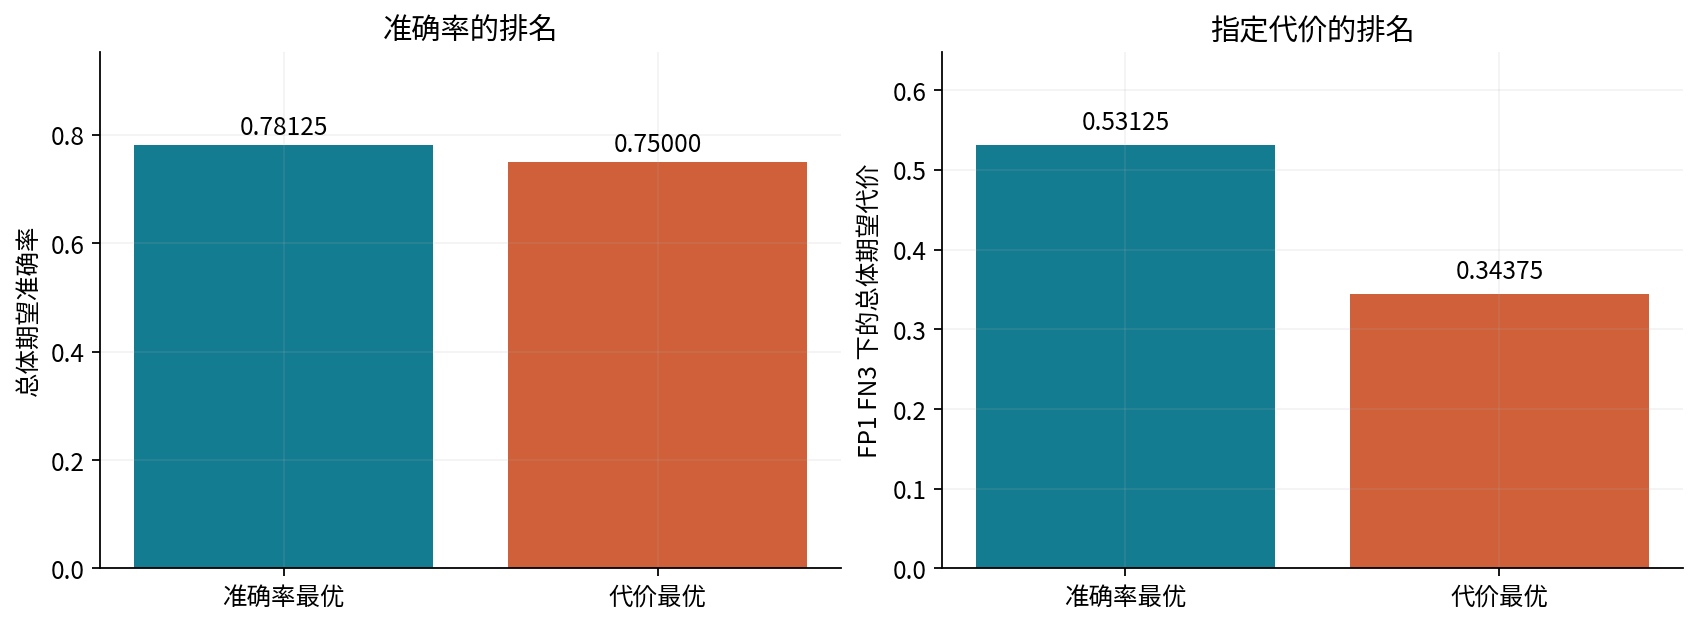

P @ C.T: [[0.    1.   ]
 [0.375 0.875]
 [0.75  0.75 ]
 [1.125 0.625]
 [1.5   0.5  ]
 [1.875 0.375]
 [2.625 0.125]
 [3.    0.   ]]


In [5]:
print('Accuracy-optimal expected accuracy:', 1-report['evaluation']['accuracy_optimal']['expected_error_rate'])
print('Cost-optimal expected accuracy:', 1-report['evaluation']['cost_optimal']['expected_error_rate'])
print('Accuracy rule actual cost:', report['evaluation']['accuracy_optimal']['expected_cost'])
print('Cost rule actual cost:', report['evaluation']['cost_optimal']['expected_cost'])
show(4)
# Independent vector expression checks the row-ledger calculation.
C = np.array(report['decision']['costs'])
print('P @ C.T:', P @ C.T)
if not np.array_equal(P @ C.T, np.array(report['decision']['risks'])):
    raise RuntimeError('Main dyadic matrix product differs from risk ledger')

In [6]:
for row in report['cost_scenarios']:
    print(row)
print('Both zero:', e.binary_threshold(0, 0))
print('All-zero risk tie:', e.risk_table([[.3, .7]], [[0, 0], [0, 0]]))
print('Swapping FP and FN changes threshold:', e.binary_threshold(3, 1))

{'FP': 1.0, 'FN': 1.0, 'threshold': 0.5, 'actions': [0, 0, 0, 0, 0, 1, 1, 1], 'expected_cost': 0.21875}
{'FP': 1.0, 'FN': 3.0, 'threshold': 0.25, 'actions': [0, 0, 0, 1, 1, 1, 1, 1], 'expected_cost': 0.34375}
{'FP': 3.0, 'FN': 1.0, 'threshold': 0.75, 'actions': [0, 0, 0, 0, 0, 0, 1, 1], 'expected_cost': 0.28125}
{'FP': 0.0, 'FN': 1.0, 'threshold': 0.0, 'actions': [0, 1, 1, 1, 1, 1, 1, 1], 'expected_cost': 0.0}
{'FP': 1.0, 'FN': 0.0, 'threshold': 1.0, 'actions': [0, 0, 0, 0, 0, 0, 0, 0], 'expected_cost': 0.0}
{'FP': 0.0, 'FN': 0.0, 'threshold': None, 'actions': [0, 0, 0, 0, 0, 0, 0, 0], 'expected_cost': 0.0}
Both zero: None
All-zero risk tie: {'rows': [{'row': 1, 'posterior': [0.3, 0.7], 'class_loss_contributions': [[0.0, 0.0], [0.0, 0.0]], 'conditional_risks': [0.0, 0.0], 'chosen_action': 0, 'tied_actions': [0, 1], 'minimum_conditional_risk': 0.0}], 'costs': [[0.0, 0.0], [0.0, 0.0]], 'risks': [[0.0, 0.0]], 'actions': [0], 'tie_rule': 'first listed action among exactly equal computed ri

Reject bounds: {'strict_reject_region': True, 'lower': 0.125, 'upper': 0.625, 'reason': 'reject strictly optimal when lower < p < upper; equality uses action order'}
With rejection: {'expected_cost': 0.25, 'per_group_risk': [0.0, 0.375, 0.375, 0.375, 0.375, 0.375, 0.125, 0.0], 'weighted_risk_contribution': [0.0, 0.046875, 0.046875, 0.046875, 0.046875, 0.046875, 0.015625, 0.0], 'actions': [0, 0, 2, 2, 2, 1, 1, 1], 'weights': [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125], 'reject_mass': 0.375}
Reject cost 3/4: {'strict_reject_region': False, 'lower': 0.25, 'upper': 0.25, 'reason': 'reject strictly optimal when lower < p < upper; equality uses action order'}
Free rejection: [0, 2, 2, 2, 2, 2, 2, 1]


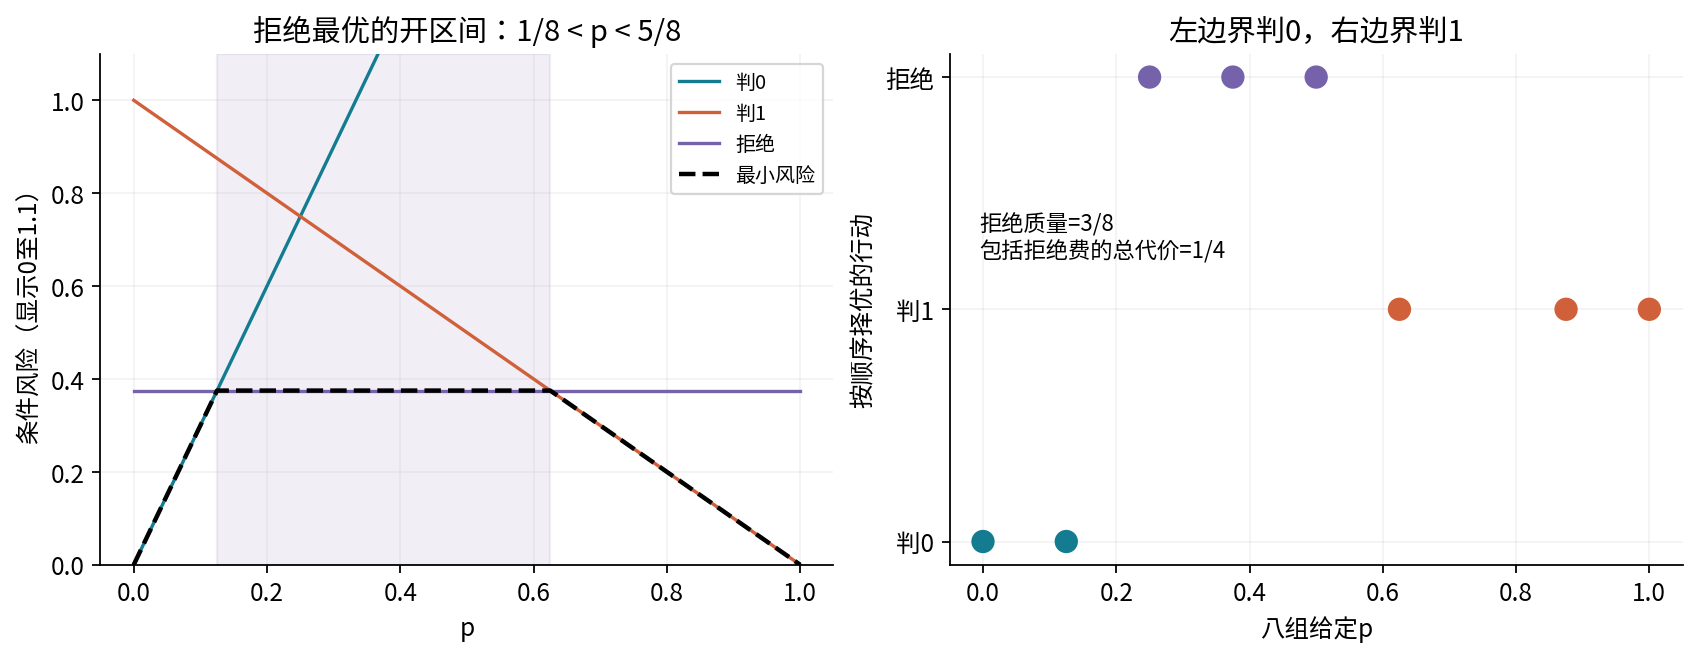

In [7]:
print('Reject bounds:', report['rejection_bounds'])
print('With rejection:', report['evaluation']['with_reject'])
print('Reject cost 3/4:', e.reject_bounds(1, 3, .75))
print('Free rejection:', e.risk_table(P, [[0, 3], [1, 0], [0, 0]])['actions'])
show(5)

Three-class probabilities: [[0.5, 0.25, 0.25], [0.25, 0.25, 0.5]]
Action-by-state costs: [[0.0, 4.0, 4.0], [1.0, 0.0, 1.0], [1.0, 3.0, 0.0]]
Full three-class decision: {'rows': [{'row': 1, 'posterior': [0.5, 0.25, 0.25], 'class_loss_contributions': [[0.0, 1.0, 1.0], [0.5, 0.0, 0.25], [0.5, 0.75, 0.0]], 'conditional_risks': [2.0, 0.75, 1.25], 'chosen_action': 1, 'tied_actions': [1], 'minimum_conditional_risk': 0.75}, {'row': 2, 'posterior': [0.25, 0.25, 0.5], 'class_loss_contributions': [[0.0, 1.0, 2.0], [0.25, 0.0, 0.5], [0.25, 0.75, 0.0]], 'conditional_risks': [3.0, 0.75, 1.0], 'chosen_action': 1, 'tied_actions': [1], 'minimum_conditional_risk': 0.75}], 'costs': [[0.0, 4.0, 4.0], [1.0, 0.0, 1.0], [1.0, 3.0, 0.0]], 'risks': [[2.0, 0.75, 1.25], [3.0, 0.75, 1.0]], 'actions': [1, 1], 'tie_rule': 'first listed action among exactly equal computed risks', 'maximum_probability_actions': [0, 2]}
Rectangular 2-action, 3-class example: {'rows': [{'row': 1, 'posterior': [0.5, 0.25, 0.25], 'class_

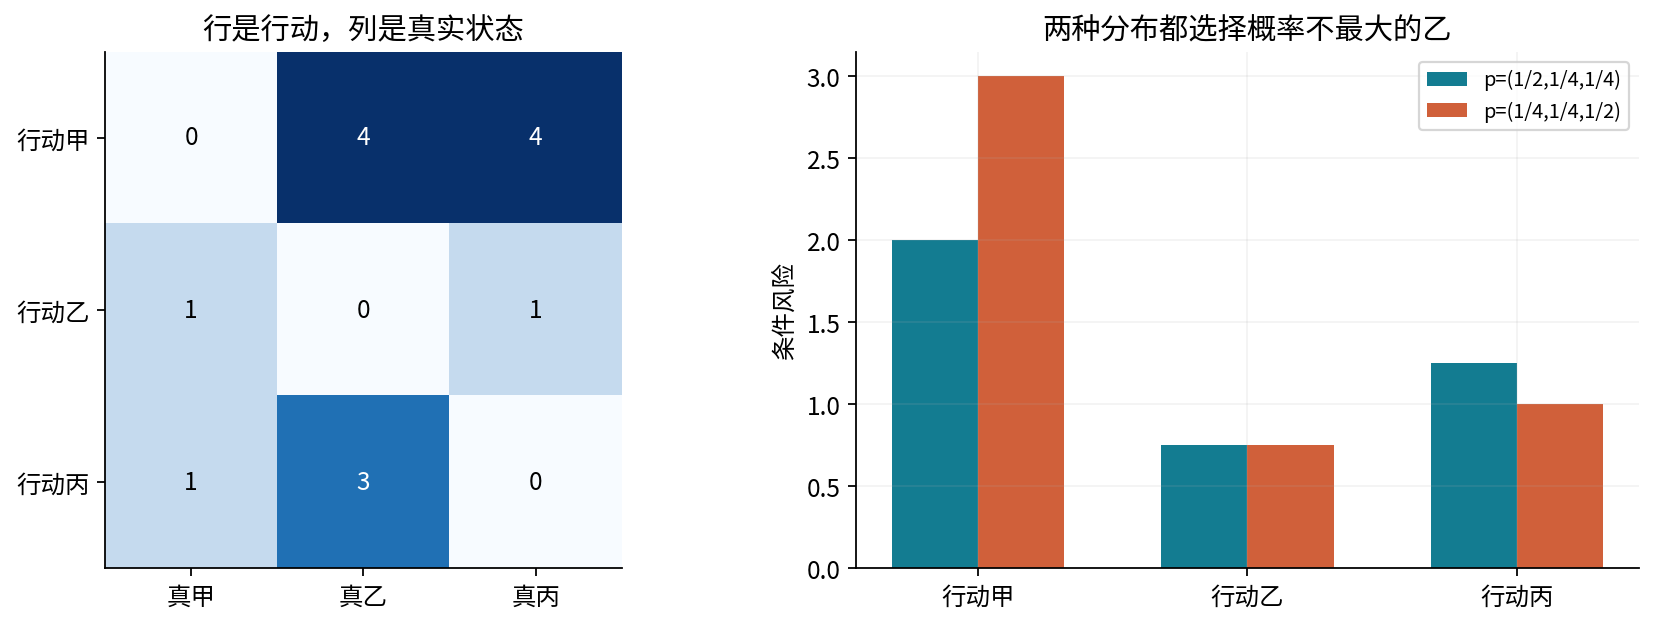

In [8]:
print('Three-class probabilities:', cfg['multiclass_probabilities'])
print('Action-by-state costs:', cfg['multiclass_costs'])
print('Full three-class decision:', report['multiclass'])
print('Rectangular 2-action, 3-class example:', e.risk_table([[.5, .25, .25]], [[0, 2, 4], [1, 1, 0]]))
show(6)

## 先验变化逐格更新
明确P(X|Y)保持不变，再比较直接Bayes与后验重加权；目标评价也换用目标边缘。

Fixed P(X|Y=0): [0.5   0.375 0.125] P(X|Y=1): [0.125 0.375 0.5  ]
source {'prior': 0.25, 'negative_joint_mass': [0.375, 0.28125, 0.09375], 'positive_joint_mass': [0.03125, 0.09375, 0.125], 'marginal': [0.40625, 0.375, 0.21875], 'positive_posterior': [0.07692307692307693, 0.25, 0.5714285714285714]}
target {'prior': 0.75, 'negative_joint_mass': [0.125, 0.09375, 0.03125], 'positive_joint_mass': [0.09375, 0.28125, 0.375], 'marginal': [0.21875, 0.375, 0.40625], 'positive_posterior': [0.42857142857142855, 0.75, 0.9230769230769231]}
Reweighted posterior: [0.42857142857142855, 0.75, 0.9230769230769231]
Stale target evaluation: {'expected_cost': 1.15625, 'per_group_risk': [1.2857142857142856, 2.25, 0.07692307692307687], 'weighted_risk_contribution': [0.28125, 0.84375, 0.03124999999999998], 'actions': [0, 0, 1], 'weights': [0.21875, 0.375, 0.40625]}
Corrected target evaluation: {'expected_cost': 0.24999999999999997, 'per_group_risk': [0.5714285714285714, 0.25, 0.07692307692307687], 'weighted_ris

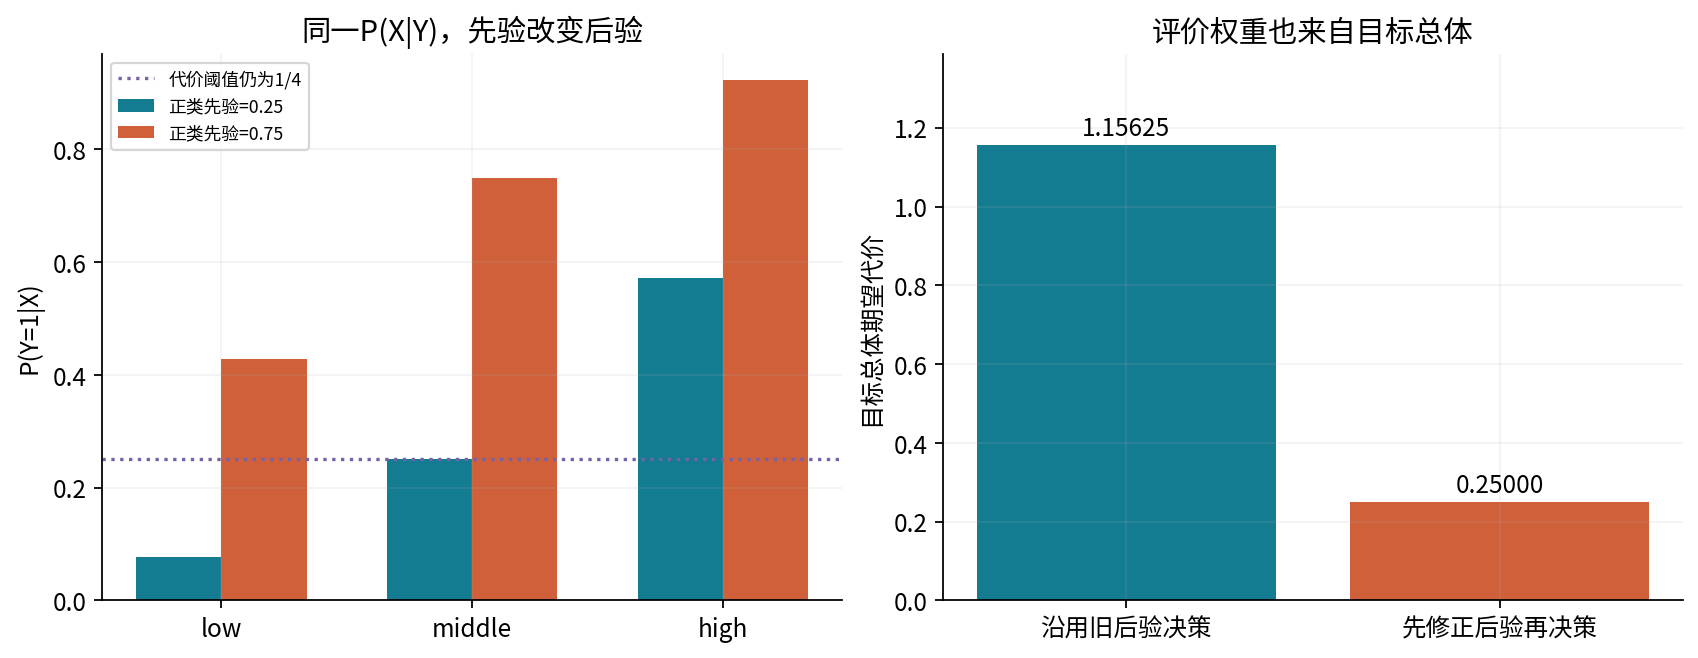

In [9]:
shift = report['label_shift']
print('Fixed P(X|Y=0):', q0, 'P(X|Y=1):', q1)
for population in ['source', 'target']:
    print(population, shift[population])
print('Reweighted posterior:', shift['corrected_positive_posterior'])
print('Stale target evaluation:', shift['stale_expected_target_cost'])
print('Corrected target evaluation:', shift['corrected_expected_target_cost'])
print('Posterior endpoints:', e.correct_prior([0, 1], .25, .75))
if not np.allclose(shift['corrected_positive_posterior'], shift['target']['positive_posterior'], atol=2e-15, rtol=2e-15):
    raise RuntimeError('Prior correction disagrees with direct Bayes')
show(7)

## 一次实际模拟和精确总体
三个政策共享2048个标签，不改种子追结果。每组固定样本数，因此标准误使用分层公式。

Sampling design: independent Bernoulli labels within each fixed stratum, fixed per-group sample count
cost_optimal {"conditional_cost_variance": [0.0, 0.984375, 1.6875, 0.234375, 0.25, 0.234375, 0.109375, 0.0], "expected_cost": 0.34375, "observed_group_mean_cost": [0.0, 0.3046875, 0.73828125, 0.625, 0.50390625, 0.37109375, 0.16015625, 0.0], "observed_mean_cost": 0.337890625, "observed_positive_counts": [0, 26, 63, 96, 127, 161, 215, 256], "sklearn_recomputed_cost": 0.337890625, "sklearn_weighted_confusion": [[0.33154296875, 0.20751953125], [0.04345703125, 0.41748046875]], "stratified_mean_standard_error": 0.014615849167085708}
accuracy_optimal {"conditional_cost_variance": [0.0, 0.984375, 1.6875, 2.109375, 2.25, 0.234375, 0.109375, 0.0], "expected_cost": 0.53125, "observed_group_mean_cost": [0.0, 0.3046875, 0.73828125, 1.125, 1.48828125, 0.37109375, 0.16015625, 0.0], "observed_mean_cost": 0.5234375, "observed_positive_counts": [0, 26, 63, 96, 127, 161, 215, 256], "sklearn_recomputed_co

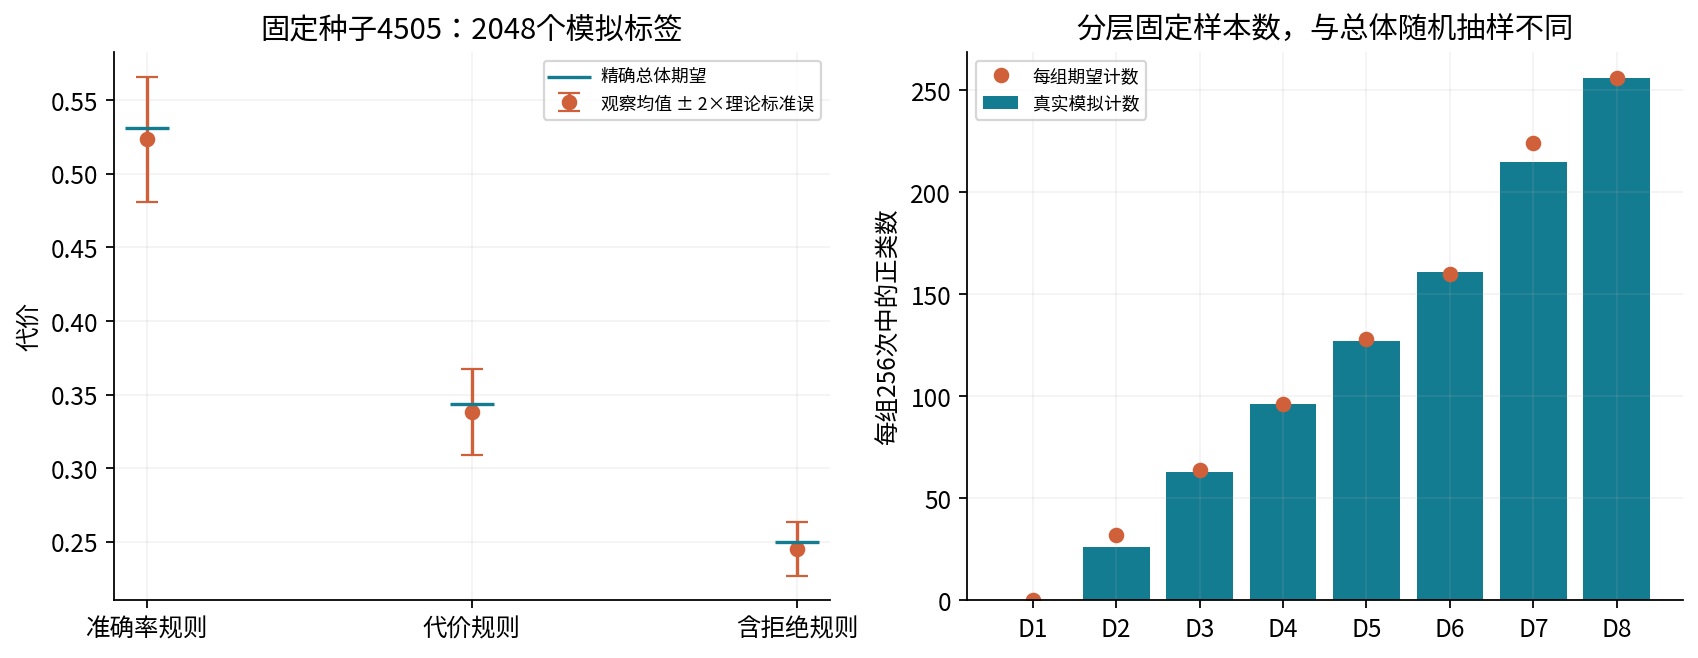

The ±2 standard-error bars illustrate scale; no exact 95% interval claim.


In [10]:
print('Sampling design:', report['simulation']['sampling'])
for name, result in report['simulation']['results'].items():
    print(name, json.dumps(result, ensure_ascii=False, sort_keys=True))
show(8)
print('The ±2 standard-error bars illustrate scale; no exact 95% interval claim.')

{'threshold': 0.0, 'expected_cost': 0.40625, 'per_group_risk': [0.0, 0.875, 0.75, 0.625, 0.5, 0.375, 0.125, 0.0], 'weighted_risk_contribution': [0.0, 0.109375, 0.09375, 0.078125, 0.0625, 0.046875, 0.015625, 0.0], 'actions': [0, 1, 1, 1, 1, 1, 1, 1], 'weights': [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]}
{'threshold': 0.125, 'expected_cost': 0.34375, 'per_group_risk': [0.0, 0.375, 0.75, 0.625, 0.5, 0.375, 0.125, 0.0], 'weighted_risk_contribution': [0.0, 0.046875, 0.09375, 0.078125, 0.0625, 0.046875, 0.015625, 0.0], 'actions': [0, 0, 1, 1, 1, 1, 1, 1], 'weights': [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]}
{'threshold': 0.25, 'expected_cost': 0.34375, 'per_group_risk': [0.0, 0.375, 0.75, 0.625, 0.5, 0.375, 0.125, 0.0], 'weighted_risk_contribution': [0.0, 0.046875, 0.09375, 0.078125, 0.0625, 0.046875, 0.015625, 0.0], 'actions': [0, 0, 0, 1, 1, 1, 1, 1], 'weights': [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]}
{'threshold': 0.375, 'expected_cost': 0.

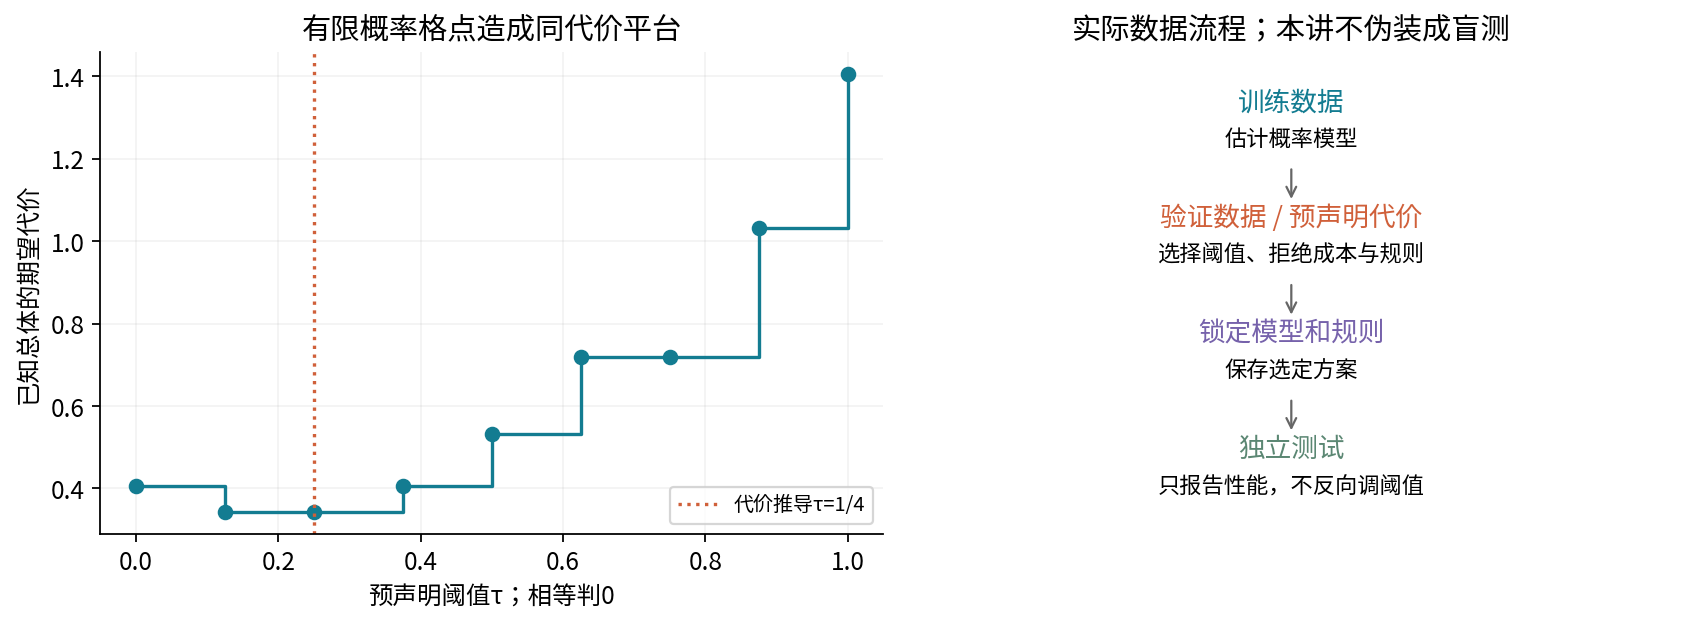

Probability-error example: excess risk 0.5 upper bound 0.8


In [11]:
for row in report['threshold_sweep']:
    print(row)
print('No observed-label threshold search occurs in this experiment.')
show(9)
eta, estimated = 3/8, 7/40
true = e.risk_table([[1-eta, eta]], [[0, 3], [1, 0]])
wrong = e.risk_table([[1-estimated, estimated]], [[0, 3], [1, 0]])
chosen = wrong['actions'][0]
excess = true['risks'][0][chosen] - min(true['risks'][0])
print('Probability-error example:', 'excess risk', excess, 'upper bound', 4*abs(eta-estimated))

In [12]:
for label, call in [
    ('bad probability sum', lambda: e.risk_table([[.2, .2]], [[0, 3], [1, 0]])),
    ('bad last cost bool', lambda: e.risk_table([[.5, .5]], [[0, 3], [1, True]])),
    ('undefined source prior correction', lambda: e.correct_prior([.5], 0, .5)),
    ('undefined empty-marginal bin', lambda: e.posterior_from_likelihoods([1, 0], [1, 0], .5))]:
    try:
        call()
    except ValueError as exc:
        print(label, 'rejected:', str(exc))
    else:
        raise RuntimeError('Invalid input was accepted: ' + label)
nearby = np.array([np.nextafter(.25, 0), .25, np.nextafter(.25, 1)])
print('Adjacent float posteriors:', nearby)
print('Threshold actions:', e.threshold_actions(nearby, .25))
print('Computed-risk actions:', e.risk_table(np.column_stack([1-nearby, nearby]), [[0, 3], [1, 0]])['actions'])

bad probability sum rejected: probabilities rows must sum to one within 1e-12
bad last cost bool rejected: costs requires a real number, not bool/string/complex
undefined source prior correction rejected: source prior outside supported finite raw range
undefined empty-marginal bin rejected: some bins have zero marginal probability; conditional undefined
Adjacent float posteriors: [0.25 0.25 0.25]
Threshold actions: [0 0 1]
Computed-risk actions: [0, 0, 1]


In [13]:
import audit
checked = audit.audit()
print('Exact policy enumeration and independent checks:', checked)
core = hashlib.sha256(e.canonical_bytes(report)).hexdigest()
if core != checked['core_sha256']:
    raise RuntimeError('Complete Notebook scientific result differs from independent audit run')
e.safe_write(BASE / 'outputs/notebook-result.json', report)
print('Complete scientific SHA256:', core)
print('Limitations:', report['limitations'])

Exact policy enumeration and independent checks: {'unit': '045', 'science': {'all_deterministic_policies': [{'actions_per_bin': 2, 'policies': 256, 'minimum': '11/32', 'optimal_policy_count': 2}, {'actions_per_bin': 3, 'policies': 6561, 'minimum': '1/4', 'optimal_policy_count': 4}], 'expected_cost_exact': {'cost_optimal': '11/32', 'accuracy_optimal': '17/32', 'reject': '1/4'}, 'oracle_shift_exact': ['1/13', '1/4', '4/7', '3/7', '3/4', '12/13'], 'rectangular_cases': 3, 'sklearn_weighted_confusion_verified': True}, 'guards': {'raw_posterior_and_cost_tail_cases': 18, 'all_config_fields_pre_RNG_checked': True, 'zero_cost_and_reject_boundaries_checked': True, 'atomic_and_alias_protection_checked': True}, 'core_sha256': '740731e6c7d15081b92a2ae68e0d6c712aff4b78ce455c8ddc71dc843fc6452e'}
Complete scientific SHA256: 740731e6c7d15081b92a2ae68e0d6c712aff4b78ce455c8ddc71dc843fc6452e
Limitations: ['supplied oracle toy probabilities, no trained/calibrated model claim', 'population costs known only 

## 写出自己的边界说明
区分已知总体、一次模拟、实际估计概率和真正独立测试。按answers.pdf完成十八题，说明哪种成本与哪种信息支持了自己的行动。